# Results report

Reads the CV and final-fit outputs under `runs/` for reporting. Run top to bottom.

Sections: sweep ranking, full 5x20 CV comparison, ROC curves, per-fold spread,
threshold metrics, and a final-submission check. Cells that need a stage you have
not run yet print a note instead of failing.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# find repo root (works wherever the kernel started)
ROOT = Path.cwd()
while not (ROOT / 'pyproject.toml').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
RUNS = ROOT / 'runs'
print('repo root:', ROOT)
print('runs dir :', RUNS, '| exists:', RUNS.exists())

repo root: /workspace/wqf7008-fb-human-or-not
runs dir : /workspace/wqf7008-fb-human-or-not/runs | exists: True


In [2]:
def load_runs(base):
    """Load every metrics.json under runs/<base>/*/ into a DataFrame."""
    rows = []
    for d in sorted((RUNS / base).glob('*/')):
        f = d / 'metrics.json'
        if not f.exists():
            continue
        j = json.loads(f.read_text())
        cm = j.get('oof_confusion_matrix', {}) or {}
        rows.append({
            'config': d.name,
            'model': j.get('model'),
            'mean_auc': j.get('mean'),
            'std_auc': j.get('std'),
            'q25_auc': j.get('q25'),
            'q10_auc': j.get('q10'),
            'n_folds': j.get('n_folds'),
            'precision': j.get('oof_precision'),
            'recall': j.get('oof_recall'),
            'f1': j.get('oof_f1'),
            'tn': cm.get('tn'), 'fp': cm.get('fp'),
            'fn': cm.get('fn'), 'tp': cm.get('tp'),
        })
    return pd.DataFrame(rows)

## 1. Sweep ranking (reduced repeats)

In [3]:
sweep = load_runs('sweep')
if sweep.empty:
    print('no runs/sweep results yet - run scripts/sweep.sh')
else:
    display(sweep.sort_values('mean_auc', ascending=False)
                 .reset_index(drop=True)[['config', 'model', 'mean_auc', 'std_auc', 'n_folds']])

,config,model,mean_auc,std_auc,n_folds
0,tffm_ch256,tffm,0.918801,0.027838,25
1,tffm_base,tffm,0.917695,0.027856,25
2,tffm_lr3e4,tffm,0.916105,0.029818,25
3,tffm_ch256_l4_lr3e4,tffm,0.916043,0.028128,25
4,tffm_l4,tffm,0.915047,0.029951,25
5,tffm_lr5e4,tffm,0.911243,0.031867,25
6,gbm_lr0.03_d4,gbm,0.892596,0.030634,25
7,gbm_ss0.7_leaf10,gbm,0.888222,0.032325,25
8,gbm_base,gbm,0.887725,0.033040,25
9,gbm_n800_d4,gbm,0.886622,0.033456,25


## 2. Full 5x20 CV comparison (reportable)

This is the protocol to report. Pick the overall best here.

In [4]:
cvf = load_runs('cv_full')
if cvf.empty:
    print('no runs/cv_full results yet - run scripts/cv_full.sh')
else:
    tbl = cvf.sort_values('mean_auc', ascending=False).reset_index(drop=True)
    display(tbl[['model', 'config', 'mean_auc', 'std_auc', 'q25_auc', 'q10_auc',
                 'precision', 'recall', 'f1', 'n_folds']])
    best = tbl.iloc[0]
    print(f"best model: {best['model']}  (mean AUC = {best['mean_auc']:.4f})")

,model,config,mean_auc,std_auc,q25_auc,q10_auc,precision,recall,f1,n_folds
0,tffm,tffm,0.917933,0.031311,0.895849,0.880155,0.256560,0.854369,0.394619,100
1,gbm,gbm,0.892172,0.029871,0.873068,0.856052,0.462810,0.543689,0.500000,100
2,hybrid,hybrid,0.863629,0.040828,0.839906,0.810221,0.170132,0.873786,0.284810,100


best model: tffm  (mean AUC = 0.9179)


## 3. Mean AUC per model (full CV)

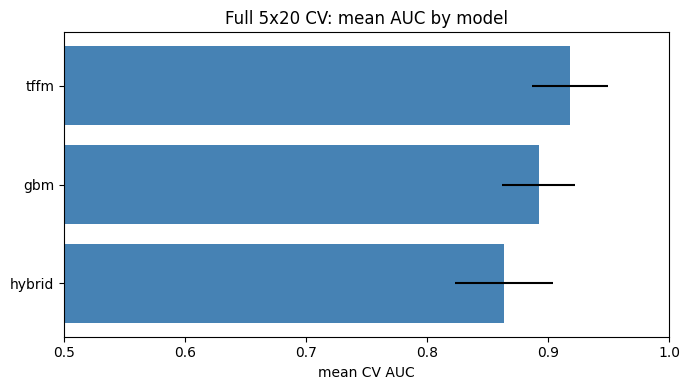

In [5]:
if cvf.empty:
    print('no runs/cv_full results yet')
else:
    t = cvf.sort_values('mean_auc')
    plt.figure(figsize=(7, 4))
    plt.barh(t['model'], t['mean_auc'], xerr=t['std_auc'], color='steelblue')
    plt.xlabel('mean CV AUC')
    plt.title('Full 5x20 CV: mean AUC by model')
    plt.xlim(0.5, 1.0)
    plt.tight_layout()
    plt.show()

## 4. ROC curves (bidder-averaged OOF, full CV)

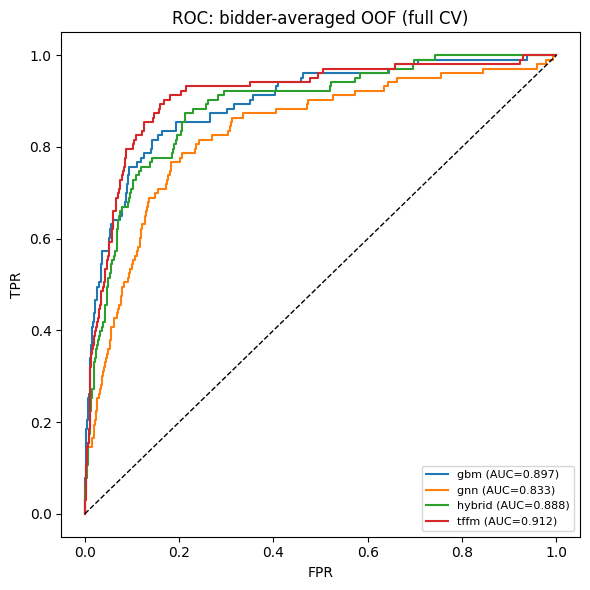

In [6]:
if cvf.empty:
    print('no runs/cv_full results yet')
else:
    plt.figure(figsize=(6, 6))
    for d in sorted((RUNS / 'cv_full').glob('*/')):
        f = d / 'oof_by_bidder.csv'
        if not f.exists():
            continue
        df = pd.read_csv(f)
        fpr, tpr, _ = roc_curve(df['y_true'], df['y_prob_mean'])
        plt.plot(fpr, tpr, label=f'{d.name} (AUC={auc(fpr, tpr):.3f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=1)
    plt.xlabel('FPR')
    plt.ylabel('TPR')
    plt.title('ROC: bidder-averaged OOF (full CV)')
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

## 5. Per-fold AUC spread (full CV)

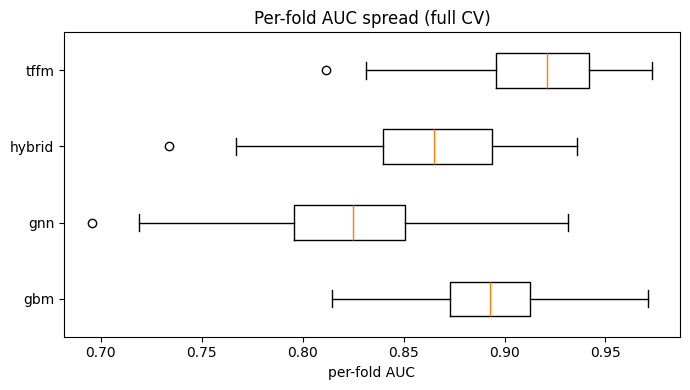

In [7]:
if cvf.empty:
    print('no runs/cv_full results yet')
else:
    data, labels = [], []
    for d in sorted((RUNS / 'cv_full').glob('*/')):
        f = d / 'folds.csv'
        if not f.exists():
            continue
        data.append(pd.read_csv(f)['auc'].values)
        labels.append(d.name)
    plt.figure(figsize=(7, 4))
    plt.boxplot(data, vert=False)
    plt.yticks(range(1, len(labels) + 1), labels)
    plt.xlabel('per-fold AUC')
    plt.title('Per-fold AUC spread (full CV)')
    plt.tight_layout()
    plt.show()

## 6. Threshold metrics and confusion matrix (full CV, threshold 0.5)

In [8]:
if cvf.empty:
    print('no runs/cv_full results yet')
else:
    display(cvf.sort_values('mean_auc', ascending=False)
               [['model', 'precision', 'recall', 'f1', 'tn', 'fp', 'fn', 'tp']]
               .reset_index(drop=True))

,model,precision,recall,f1,tn,fp,fn,tp
0,tffm,0.256560,0.854369,0.394619,1655,255,15,88
1,gbm,0.462810,0.543689,0.500000,1845,65,47,56
2,hybrid,0.170132,0.873786,0.284810,1471,439,13,90


## 7. Final fit + submission check

In [9]:
final = RUNS / 'final'
if not final.exists():
    print('no runs/final yet - run scripts/train_eval.sh')
else:
    for d in sorted(final.glob('*/')):
        sub, ck = d / 'submission.csv', d / 'ckpt.pt'
        print(f"{d.name:8} ckpt={'yes' if ck.exists() else 'no':3} "
              f"submission={'yes' if sub.exists() else 'no'}")
        if sub.exists():
            s = pd.read_csv(sub)
            print(f'   {len(s)} rows, columns={list(s.columns)}')

no runs/final yet - run scripts/train_eval.sh
